# Tarea 4 - Montenegro Maximiliano 

## Transformacipon de un filtro pasabajo a pasabanda

### 1- Datos:
![ver PNG](datos.png)

normalizando con $f_0$ ,  datos normalizados queda:
$$Bw = \frac{f_0}{Q} = \frac{1}{5} = 0,2$$
$$
\begin{cases}
f_2 - f_1 = f_0 \\
f_2f_1=f_0^2 \\
\end{cases}
\qquad\Rightarrow\qquad
\begin{cases}
f_2 - f_! = 0,2\\
f_2f_1=1
\end{cases}
\qquad\Rightarrow\qquad
\begin{cases}
f_2 = 0,2 + f_1\\
(0,2 + f_1)f_1=1
\end{cases}
\qquad\Rightarrow\qquad
\begin{cases}
f_1 = 0,9\\
f_2 = 1,1
\end{cases}
$$
$$f_{01} = 0,77 Hz \qquad f_1 = 0,9 Hz \qquad f_0 = 1 Hz \qquad f_2 = 1,1  Hz\qquad f_{02} = 1,63 Hz$$

## 2- Eleccion de filtro:
$$\alpha_{max} = 0,5 \qquad\Rightarrow\qquad \alpha_{min_1} = 16 \,dB \qquad,\qquad \alpha_{min_2} = 24 \,dB$$
$$\epsilon^2=10^\frac{\alpha_{max}}{10}-1 \qquad\Rightarrow\qquad \epsilon ^2 = 0,122$$
$$\Omega=\frac{1}{B\omega}\frac{\omega^2-\omega_0^2}{\omega}$$
$$\Omega\big|_{\omega=1,63}=\frac{1}{0,2}\frac{1,63^2 - 1}{1,63}\approx5,13 \qquad\Rightarrow\qquad \Omega\big|_{\omega=0,77}=\frac{1}{0,2}\frac{0,77^2 - 1}{0,77}\approx-2,61$$
$$\alpha_{min} = 10 \log(1 + \epsilon^2cosh^2(ncosh^1(\Omega)))$$
Se obtiene los siguientes valores:
$$\alpha_{min2}\big|_{n=2} = 25,14 \,dB\qquad\Rightarrow\qquad\alpha_{min1}\big|_{n=3}=26,89 \,dB$$
se elige el de orden 3, debido a que es le más exigidao
$$T(s)T(-s) = \frac{1}{1+\epsilon^2(C_3(\omega))^2} \qquad\Rightarrow\qquad C_3 = 4\omega^3 - 3 \omega$$
$$T(s)T(-s) = \frac{1}{1+\epsilon^2(4\omega^3 - 3\omega)^2}$$
mediante desarrollo algrebraico se obtiene l asiguiete experesión:
$$
\Huge
T(s)T(-s) = -\frac{1}{16\epsilon^2}\frac{1}{s^6 + \frac{24}{16}s^4 + \frac{9}{16}s^2 - \frac{1}{16\epsilon^2}}
$$

#### Aproximaciones de Chevyschev normalizado

#### Chebyshev1_ord_3

<IPython.core.display.Math object>

<IPython.core.display.Math object>

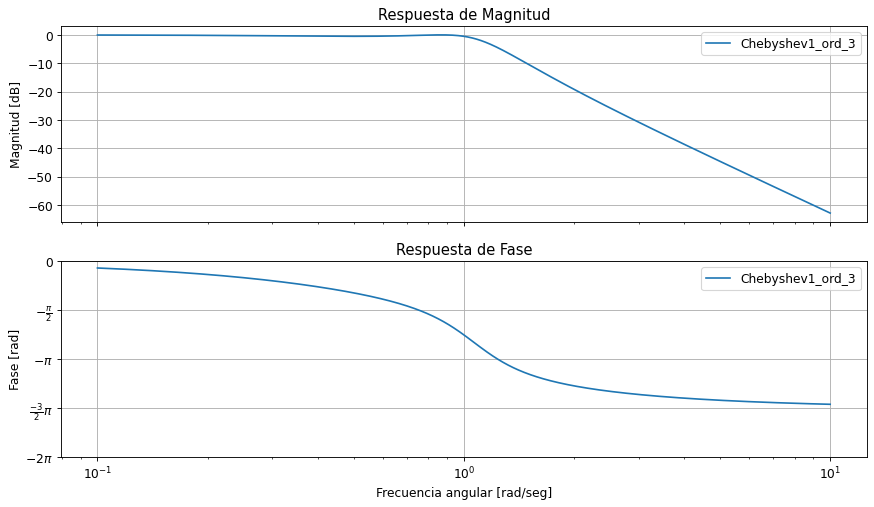

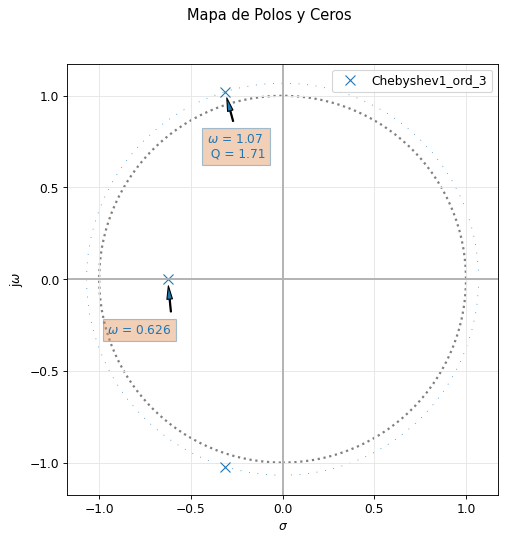

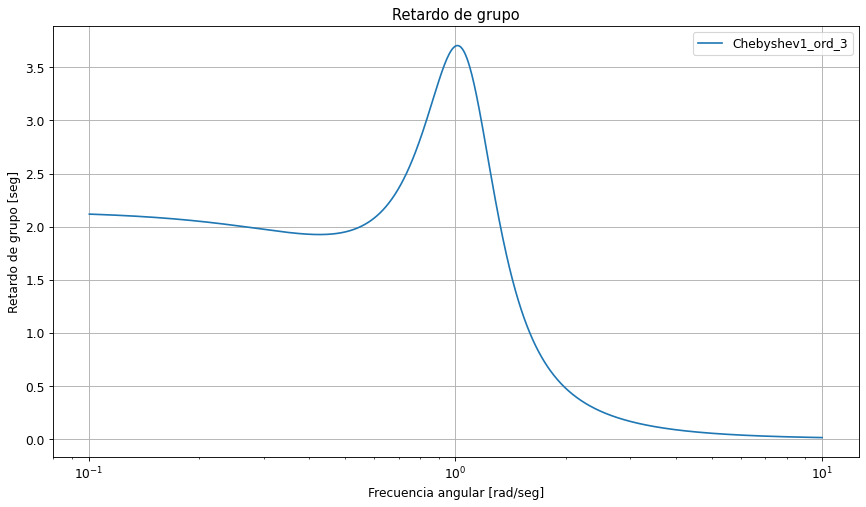

In [2]:
%run tarea4_montenegro.py

## 3- Para el transformar el pasabajo en pasabanda, se debe frealizar:
$$S=Q\frac{s^2 +1}{s}$$
$$\frac{\theta}{s+\theta} \qquad\to\qquad \frac{1}{Q}\frac{s}{s^2 + \frac{\theta}{Q}s + 1}$$
$$
\Huge
\frac{b}{s^2 +sa +b} \qquad\to\qquad \frac{b}{Q^2}\frac{s}{s^4 + \frac{a}{Q}s^3 + (2 + \frac{b^2}{Q^2})s^2 + \frac{a}{Q}s + 1}
=
\frac{\omega_{01}}{Q_1}\frac{s}{s^2 + \frac{\omega_{01}}{Q_1}s + \omega_{01}^2}
+
\frac{\omega_{02}}{Q_2}\frac{s}{s^2 + \frac{\omega_{02}}{Q_2}s + \omega_{02}^2}
$$

## Se procedera a obtener el filtro pasababda total y por SOS mas la respuesta en frecuencia

#### Filtro pasabajos obtenido

<IPython.core.display.Math object>

#### Pasabanda obtenido para Q=5 (coeficientes de los polinomios)

#### Como cociente de polinomios

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

#### SOS 2

<IPython.core.display.Math object>

#### SOS 3

<IPython.core.display.Math object>

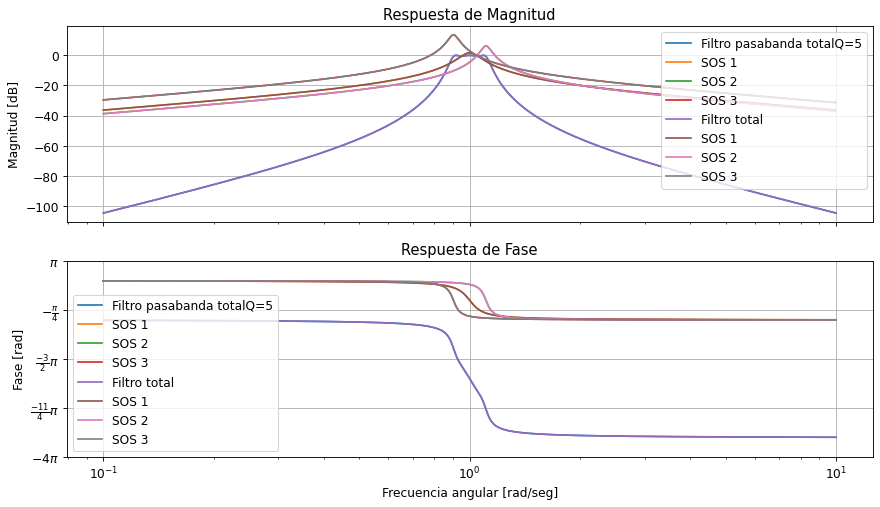

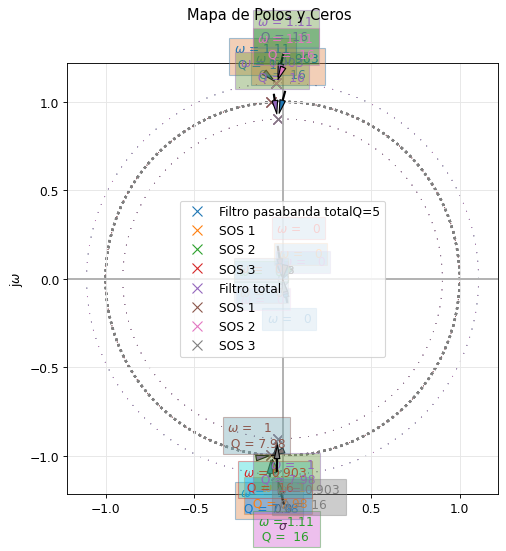

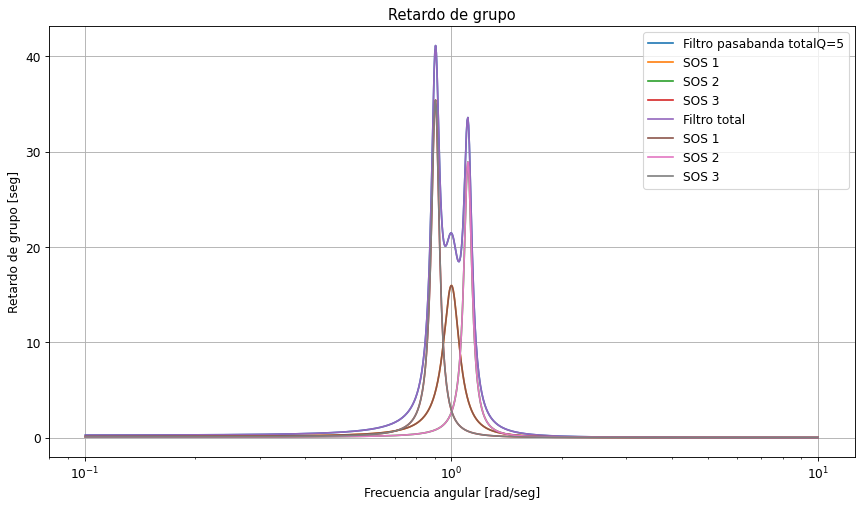

In [2]:
%run tarea4_scripy_pasabanda.py
from IPython.display import display, HTML

import warnings
from scipy.signal import BadCoefficients

warnings.filterwarnings("ignore", category=BadCoefficients)

## Bonus - Circuito armado y simuladom en LTSpice
![ver PNG](circuito.png)

## Respuesta en frecuencia:
![ver PNG](transferencia.png)

## pasabajos -> Pasa-altos
Se parte de la transferencia pasabajos obtenida en el punto anterior:

$$
T_{PB}(s)=
\frac{0.7157}
{s^3+1.253s^2+1.535s+0.7157}
$$

Aplicando la transformación pasabajos a pasaaltos normalizada:

$$
s \rightarrow \frac{1}{s}
$$

se obtiene:

$$
T_{PA}(s)=
\frac{0.7157}
{\left(\frac{1}{s}\right)^3
+1.253\left(\frac{1}{s}\right)^2
+1.535\left(\frac{1}{s}\right)
+0.7157}
$$

Multiplicando numerador y denominador por $s^3$:

$$
T_{PA}(s)=
\frac{0.7157\,s^3}
{1+1.253s+1.535s^2+0.7157s^3}
$$

Reordenando los términos del denominador:

$$
T_{PA}(s)=
\frac{0.7157\,s^3}
{0.7157s^3+1.535s^2+1.253s+1}
$$

Dividiendo numerador y denominador por $0.7157$:

$$
T_{PA}(s)=
\frac{s^3}
{s^3+\frac{1.535}{0.7157}s^2+\frac{1.253}{0.7157}s+\frac{1}{0.7157}}
$$

Calculando los coeficientes:

$$
\frac{1.535}{0.7157}\approx 2.145
$$

$$
\frac{1.253}{0.7157}\approx 1.750
$$

$$
\frac{1}{0.7157}\approx 1.397
$$

Por lo tanto, la transferencia pasaaltos obtenida es:

$$
T_{PA}(s)=
\frac{s^3}
{s^3+2.145s^2+1.750s+1.397}
$$

# Tarea realizada a mano
<iframe
    src="Tarea%204_260618_005424.pdf"
    width="100%"
    height="800px">
</iframe>

In [1]:
from IPython.display import IFrame

IFrame("Tarea 4_260618_005424.pdf", width=1000, height=800)